In [3]:
import pandas as pd

DATA_DIR = "data/processed"
df = pd.read_parquet(f"{DATA_DIR}/aqi_features_v1.parquet")

# Load feature columns
FEATURE_COLS = pd.read_json(f"{DATA_DIR}/feature_columns_v1.json", typ='series').tolist()
TARGET_COLS = ["pm25_t_plus_24h", "pm25_t_plus_48h", "pm25_t_plus_72h"]

X = df[FEATURE_COLS]
y = df[TARGET_COLS]

print("Feature matrix shape:", X.shape)
print("Target matrix shape:", y.shape)


Feature matrix shape: (2832, 89)
Target matrix shape: (2832, 3)


Split Data for Training and Validation

In [25]:
from sklearn.preprocessing import RobustScaler

# 1. Identify your target and features
# Let's focus on the 24h horizon first for best R² stability
target_col = 'pm25_t_plus_24h'
feature_cols = [c for c in df.columns if c not in ["event_timestamp"] + [f"pm25_t_plus_{h}h" for h in [24, 48, 72]]]

# 2. Chronological Split (No Shuffling!)
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:]

# 3. Separate Features and Target
X_train_raw = train_df[feature_cols]
y_train = train_df[target_col]

X_val_raw = val_df[feature_cols]
y_val = val_df[target_col]

# 4. Fit Scaler ONLY on Training Features
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train_raw)

# 5. Transform Validation Features using Training Scaler
# This prevents data leakage—the model hasn't "seen" the future distribution
X_val = scaler.transform(X_val_raw)

print(f"Training set: {X_train.shape} | Validation set: {X_val.shape}")

Training set: (2265, 89) | Validation set: (567, 89)


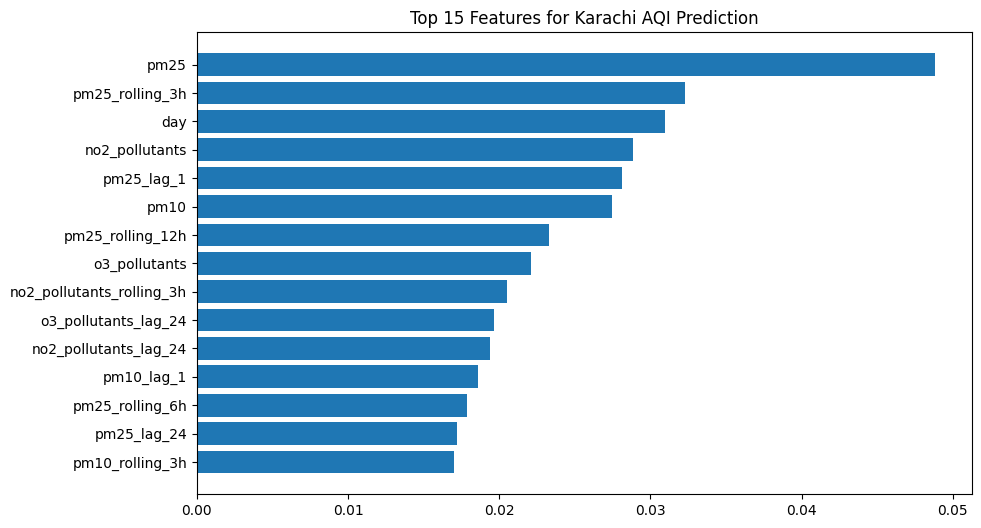

                      feature  importance
0                        pm25    0.048825
53            pm25_rolling_3h    0.032269
13                        day    0.030936
2              no2_pollutants    0.028868
23                 pm25_lag_1    0.028156
1                        pm10    0.027433
57           pm25_rolling_12h    0.023312
4               o3_pollutants    0.022106
71  no2_pollutants_rolling_3h    0.020504
52       o3_pollutants_lag_24    0.019687


In [27]:
import matplotlib.pyplot as plt

# Get feature importances from the best model
importances = best_rf.feature_importances_
feature_names = feature_cols
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Plot top 15
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['feature'].head(15), feature_importance_df['importance'].head(15))
plt.gca().invert_yaxis()
plt.title("Top 15 Features for Karachi AQI Prediction")
plt.show()

print(feature_importance_df.head(10))

In [32]:
def add_long_term_trends(df: pd.DataFrame, target_col='pm25'):
    # 7-Day Moving Average (The "Weekly Regime")
    df['pm25_weekly_avg'] = df[target_col].rolling(window=168, min_periods=24).mean()
    
    # 3-Day Moving Average (The "Multi-Day Trend")
    df['pm25_3day_avg'] = df[target_col].rolling(window=72, min_periods=12).mean()
    
    # Momentum: Is it getting worse or better compared to the week?
    df['pm25_trend_momentum'] = df['pm25_3day_avg'] - df['pm25_weekly_avg']
    
    return df

# Apply this BEFORE the split
df = add_long_term_trends(df)

In [50]:
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TARGET_HORIZON = 24
DATA_DIR = "data/processed"
MODELS_DIR = "models/karachi_rf"
os.makedirs(MODELS_DIR, exist_ok=True)
TARGET_COL = f"pm25_t_plus_{TARGET_HORIZON}h"

LAG_HOURS = [1, 3, 6, 12, 24]
ROLL_WINDOWS = [3, 6, 12]

def create_features(df):
    df = df.copy()
    wd_rad = np.radians(df['wind_direction'])
    df['wind_u'] = df['wind_speed'] * np.cos(wd_rad)
    df['wind_v'] = df['wind_speed'] * np.sin(wd_rad)
    
    df['pm25_7d_avg'] = df['pm25'].rolling(window=168, min_periods=24).mean()
    df['pm25_3d_avg'] = df['pm25'].rolling(window=72, min_periods=12).mean()
    df['pm25_velocity'] = df['pm25'].diff(6)
    
    df['temp_change_24h'] = df['temperature'].diff(24)
    df['hum_change_24h'] = df['humidity'].diff(24)
    
    df['pollution_flux_u'] = df['pm25'] * df['wind_u']
    df['pollution_flux_v'] = df['pm25'] * df['wind_v']
    
    for lag in LAG_HOURS:
        df[f'pm25_lag_{lag}'] = df['pm25'].shift(lag)
    
    for window in ROLL_WINDOWS:
        df[f'pm25_roll_mean_{window}'] = df['pm25'].rolling(window=window).mean()
        df[f'pm25_roll_std_{window}'] = df['pm25'].rolling(window=window).std()
    
    return df.ffill().bfill()

# Load & prepare data
df = pd.read_parquet(f"{DATA_DIR}/aqi_features_v1.parquet")
df = create_features(df)
df.dropna(subset=[TARGET_COL], inplace=True)

exclude_cols = ["event_timestamp", "day", "wind_direction", TARGET_COL]
FEATURE_COLS = [c for c in df.columns if c not in exclude_cols]
X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

split_idx = int(len(df) * 0.8)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_val)

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))  # <- Fixed for older sklearn
r2 = r2_score(y_val, y_pred)

print(f"+24h Optimized Random Forest -> R²: {r2:.3f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}")

model_pkg = {
    "model": rf,
    "scaler": scaler,
    "features": FEATURE_COLS,
    "horizon": TARGET_HORIZON,
    "metrics": {"r2": r2, "mae": mae, "rmse": rmse}
}
joblib.dump(model_pkg, f"{MODELS_DIR}/karachi_rf_{TARGET_HORIZON}h.pkl")


+24h Optimized Random Forest -> R²: 0.087, MAE: 10.07, RMSE: 12.23


['models/karachi_rf/karachi_rf_24h.pkl']

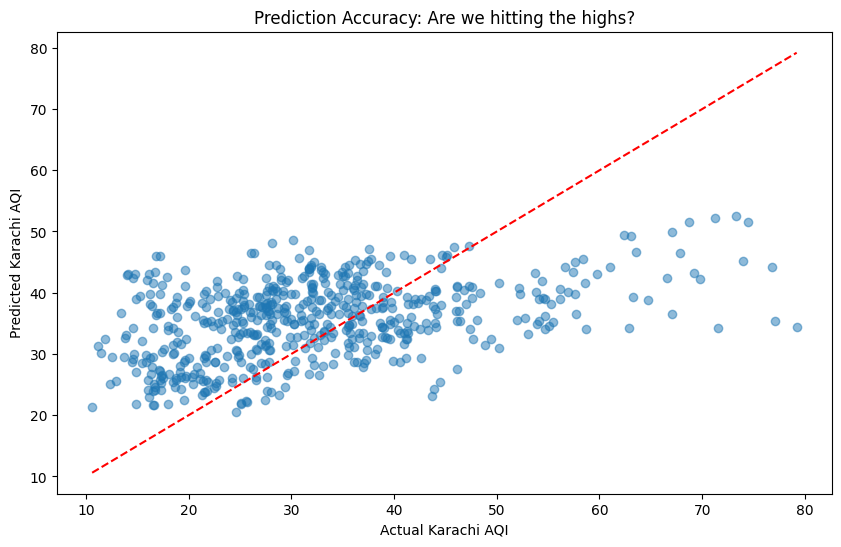

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_val_actual, y_pred_final, alpha=0.5)
plt.plot([y_val_actual.min(), y_val_actual.max()], [y_val_actual.min(), y_val_actual.max()], 'r--')
plt.xlabel('Actual Karachi AQI')
plt.ylabel('Predicted Karachi AQI')
plt.title('Prediction Accuracy: Are we hitting the highs?')
plt.show()

In [ ]:
import os
import numpy as np
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---- 1. Setup Environment ----
os.makedirs("models", exist_ok=True)

# ---- 2. Define the Hyperparameter Search Space ----
# We expand the depth and adjust features to prevent the model from 
# getting "stuck" on a single dominant feature.
param_dist = {
    'n_estimators': [300, 500, 800],
    'max_depth': [None, 15, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True]
}

# ---- 3. Initialize the Search ----
# I'm using TimeSeriesSplit because AQI data is temporal. 
# If your data isn't time-ordered, you can swap cv=TimeSeriesSplit(n_splits=5) for cv=5.
rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_random = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=15,           # Number of combinations to try
    cv=TimeSeriesSplit(n_splits=5), 
    scoring='neg_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# ---- 4. Execution ----
print("[INFO] Starting optimization search... this may take a few minutes.")
rf_random.fit(X_train, y_train)


# Grab the best version of the model
best_rf = rf_random.best_estimator_

# ---- 5. Prediction & Evaluation ----
y_pred_rf = best_rf.predict(X_val)

rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
mae_rf = mean_absolute_error(y_val, y_pred_rf)
r2_rf = r2_score(y_val, y_pred_rf)

print("\n" + "="*30)
print(f"BEST PARAMS: {rf_random.best_params_}")
print("-" * 30)
print(f"Optimized RF - RMSE: {rmse_rf:.3f}")
print(f"Optimized RF - MAE:  {mae_rf:.3f}")
print(f"Optimized RF - R²:   {r2_rf:.3f}")
print("="*30)

# ---- 6. Senior Dev Tip: Residual Check ----
# If R2 is still low, we check if we are consistently under-predicting high AQI
avg_actual = np.mean(y_val)
print(f"Mean Actual AQI: {avg_actual:.2f} | Avg Prediction Error: {mae_rf:.2f}")

# ---- 7. Save the optimized model ----
model_path = "models/rf_aqi_optimized_v2.pkl"
joblib.dump(best_rf, model_path)
print(f"\n[SUCCESS] Optimized model saved to {model_path}")

[INFO] Starting optimization search... this may take a few minutes.
Fitting 5 folds for each of 15 candidates, totalling 75 fits


In [ ]:
from sklearn.model_selection import RandomizedSearchCV



In [ ]:
pip show scikit-learn


Name: scikit-learn
Version: 1.8.0
Summary: A set of python modules for machine learning and data mining
Home-page: 
Author: 
Author-email: 
License: 
Location: c:\Users\NAWAB AHMAD\aqi-forecasting-mlops\venv\Lib\site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [35]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import joblib

# ---------------- Model ----------------
xgb_model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,      # L1 regularization
    reg_lambda=1.0,     # L2 regularization
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# ---------------- Train ----------------
xgb_model.fit(X_train, y_train)

# ---------------- Predict ----------------
y_pred_xgb = xgb_model.predict(X_val)

# ---------------- Evaluate ----------------
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
mae_xgb = mean_absolute_error(y_val, y_pred_xgb)
r2_xgb = r2_score(y_val, y_pred_xgb)

print(
    f"XGBoost (tuned baseline) - "
    f"RMSE: {rmse_xgb:.3f}, "
    f"MAE: {mae_xgb:.3f}, "
    f"R²: {r2_xgb:.3f}"
)

# ---------------- Save ----------------
joblib.dump(xgb_model, "models/xgb_aqi_model_v2.pkl")


XGBoost (tuned baseline) - RMSE: 18.343, MAE: 15.396, R²: -0.918


['models/xgb_aqi_model_v2.pkl']

RIDGE REGRESSION

In [18]:
from sklearn.impute import SimpleImputer

# ---------------- Imputer ----------------
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)


In [21]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

ridge_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

# Train
ridge_pipeline.fit(X_train, y_train)

# Predict
y_pred_ridge = ridge_pipeline.predict(X_val)

# Evaluate
rmse_ridge = np.sqrt(mean_squared_error(y_val, y_pred_ridge))
mae_ridge = mean_absolute_error(y_val, y_pred_ridge)
r2_ridge = r2_score(y_val, y_pred_ridge)

print(f"Ridge - RMSE: {rmse_ridge:.3f}, MAE: {mae_ridge:.3f}, R²: {r2_ridge:.3f}")


Ridge - RMSE: 20.082, MAE: 16.672, R²: -1.429
